# Multiclass Iris Classification

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import LabelEncoder

## Dataset

In [2]:
path = "iris.csv"
dataset = pd.read_csv(path)

print(dataset.columns.values)

['Id' 'SepalLengthCm' 'SepalWidthCm' 'PetalLengthCm' 'PetalWidthCm'
 'Species']


In [3]:
# Load the alternate Iris file and assign column names

path = "irisNoNames.csv"

dataset = pd.read_csv(path)

columnNames = ['Id', 'SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm','Species']
dataset.columns = columnNames

print(dataset.columns.values)
dataset

['Id' 'SepalLengthCm' 'SepalWidthCm' 'PetalLengthCm' 'PetalWidthCm'
 'Species']


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,2,4.9,3.0,1.4,0.2,Iris-setosa
1,3,4.7,3.2,1.3,0.2,Iris-setosa
2,4,4.6,3.1,1.5,0.2,Iris-setosa
3,5,5.0,3.6,1.4,0.2,Iris-setosa
4,6,5.4,3.9,1.7,0.4,Iris-setosa
...,...,...,...,...,...,...
144,146,6.7,3.0,5.2,2.3,Iris-virginica
145,147,6.3,2.5,5.0,1.9,Iris-virginica
146,148,6.5,3.0,5.2,2.0,Iris-virginica
147,149,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
X = dataset.copy()
X = X.drop(columns = ['Id','Species'])
y = dataset['Species']

print(y[:5])
print(X[:5])

0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            4.9           3.0            1.4           0.2
1            4.7           3.2            1.3           0.2
2            4.6           3.1            1.5           0.2
3            5.0           3.6            1.4           0.2
4            5.4           3.9            1.7           0.4


In [5]:
y.unique() # Available target classes

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [6]:
class_mapping = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
y = dataset['Species'].map(class_mapping)
print(y)

0      0
1      0
2      0
3      0
4      0
      ..
144    2
145    2
146    2
147    2
148    2
Name: Species, Length: 149, dtype: int64


## Train-test split

In [7]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size = 0.3,
    random_state=10
)
print(len(dataset))
print(len(x_train))
print(len(x_test))


149
104
45


In [8]:
print(x_train.shape)
print(y_train.shape)
print(y_train[:10])

(104, 4)
(104,)
126    2
68     1
91     1
63     1
142    2
116    2
14     0
48     0
59     1
20     0
Name: Species, dtype: int64


## TensorFlow model

### Architecture

In [9]:
model = Sequential(
    [ 
        Dense(16, activation = 'relu'),
        Dense(32, activation = 'relu'),
        Dense(3, activation = 'softmax') 
    ]
)

In [11]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(0.001),
    metrics=['accuracy'],
)

model.fit(
    x_train,y_train,
    epochs=200,
    validation_data=(x_test, y_test)
)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.3366 - loss: 1.9919 - val_accuracy: 0.4000 - val_loss: 1.5010
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3200 - loss: 1.7202 - val_accuracy: 0.4000 - val_loss: 1.2860
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3137 - loss: 1.4555 - val_accuracy: 0.4000 - val_loss: 1.1087
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2845 - loss: 1.2707 - val_accuracy: 0.4000 - val_loss: 0.9800
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3446 - loss: 1.0247 - val_accuracy: 0.6000 - val_loss: 0.8972
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5686 - loss: 0.9169 - val_accuracy: 0.7778 - val_loss: 0.8534
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6762 - loss: 0.8508 - val_accuracy: 0.6000 - val_loss: 0.8413
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6825 - loss: 0.8059 - val_accuracy: 0.6000 - val_loss:

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,171 (8.48 KB)

 Trainable params: 723 (2.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,448 (5.66 KB)

### Predictions

In [14]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy * 100:.2f}%')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9748 - loss: 0.1359
Test loss: 0.1231
Test accuracy: 97.78%


In [15]:
# Generate predictions with model.predict()
print("prediction:")
print(x_test[0:3])
print(y_test[0:3])
prediction = model.predict(x_test[:3])
print(prediction)

prediction:
     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
81             5.8           2.7            3.9           1.2
132            6.3           2.8            5.1           1.5
10             4.8           3.4            1.6           0.2
81     1
132    2
10     0
Name: Species, dtype: int64
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
[[6.4621870e-03 9.8062611e-01 1.2911648e-02]
 [1.1809953e-04 3.6148223e-01 6.3839960e-01]
 [9.9362576e-01 6.3642124e-03 1.0024874e-05]]


In [16]:
predictions = model.predict(x_test)
print("predictions = \n", predictions[:5])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
predictions = 
 [[6.46218983e-03 9.80626106e-01 1.29116410e-02]
 [1.18099582e-04 3.61482471e-01 6.38399243e-01]
 [9.93625641e-01 6.36420911e-03 1.00248735e-05]
 [6.49581570e-03 9.60043669e-01 3.34605314e-02]
 [1.78239064e-03 8.39030504e-01 1.59187138e-01]]


In [17]:
y_pred = []

for i in range(len(predictions)):
    y_pred.append(np.argmax(predictions[i]))
    print( f"{predictions[i]}, category: {np.argmax(predictions[i])}")

print("Test set score: {:.2f}".format(np.mean(y_pred == y_test.ravel())))

[0.00646219 0.9806261  0.01291164], category: 1
[1.1809958e-04 3.6148247e-01 6.3839924e-01], category: 2
[9.93625641e-01 6.36420911e-03 1.00248735e-05], category: 0
[0.00649582 0.96004367 0.03346053], category: 1
[0.00178239 0.8390305  0.15918714], category: 1
[0.02501909 0.96085036 0.01413053], category: 1
[0.00425944 0.8803233  0.11541722], category: 1
[0.00108145 0.56306607 0.4358524 ], category: 1
[9.9465930e-01 5.3291046e-03 1.1524343e-05], category: 0
[3.0921242e-06 2.1703016e-02 9.7829390e-01], category: 2
[8.2083097e-06 6.7163892e-02 9.3282795e-01], category: 2
[2.8941909e-06 1.8992076e-02 9.8100495e-01], category: 2
[0.00686942 0.980293   0.01283769], category: 1
[9.9254119e-01 7.4380981e-03 2.0694037e-05], category: 0
[9.9330741e-01 6.6849967e-03 7.5488210e-06], category: 0
[3.27750911e-07 1.13152005e-02 9.88684475e-01], category: 2
[2.5548039e-05 1.0591588e-01 8.9405853e-01], category: 2
[9.9415207e-01 5.8381767e-03 9.7389047e-06], category: 0
[9.96330857e-01 3.65582341e-03 

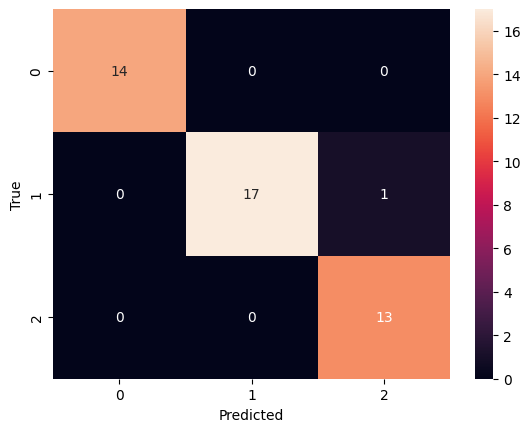

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()